Demo of a simple OCR pipeline

In [1]:
import os
import cv2
import pyewts
import random
import numpy as np
import tensorflow as tf
import keras.backend as K
import onnxruntime as ort
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from natsort import natsorted
from keras.models import Model
from Lib.Modules import LineDetector, OCRInference
from Lib.Exporter import PageXML, ProdigyLines, TextOutput
from Lib.Utils import IIIFDownloader
from IPython.display import Image as ShowImage

from config import model_characters

In [2]:
line_model_path = "Models\LineModels\khyentse_wangpo_q.onnx"
keras_ocr_weights = "Models\\OCRModels\\khyentse_wangpo_easter.hdf5"
charset = model_characters
wylie_converter = pyewts.pyewts()

ocr_model = OCRInference(model_weights=keras_ocr_weights, model_characters=charset)
line_detector = LineDetector(line_model_path)

#### Inference on line samples

Images: 5


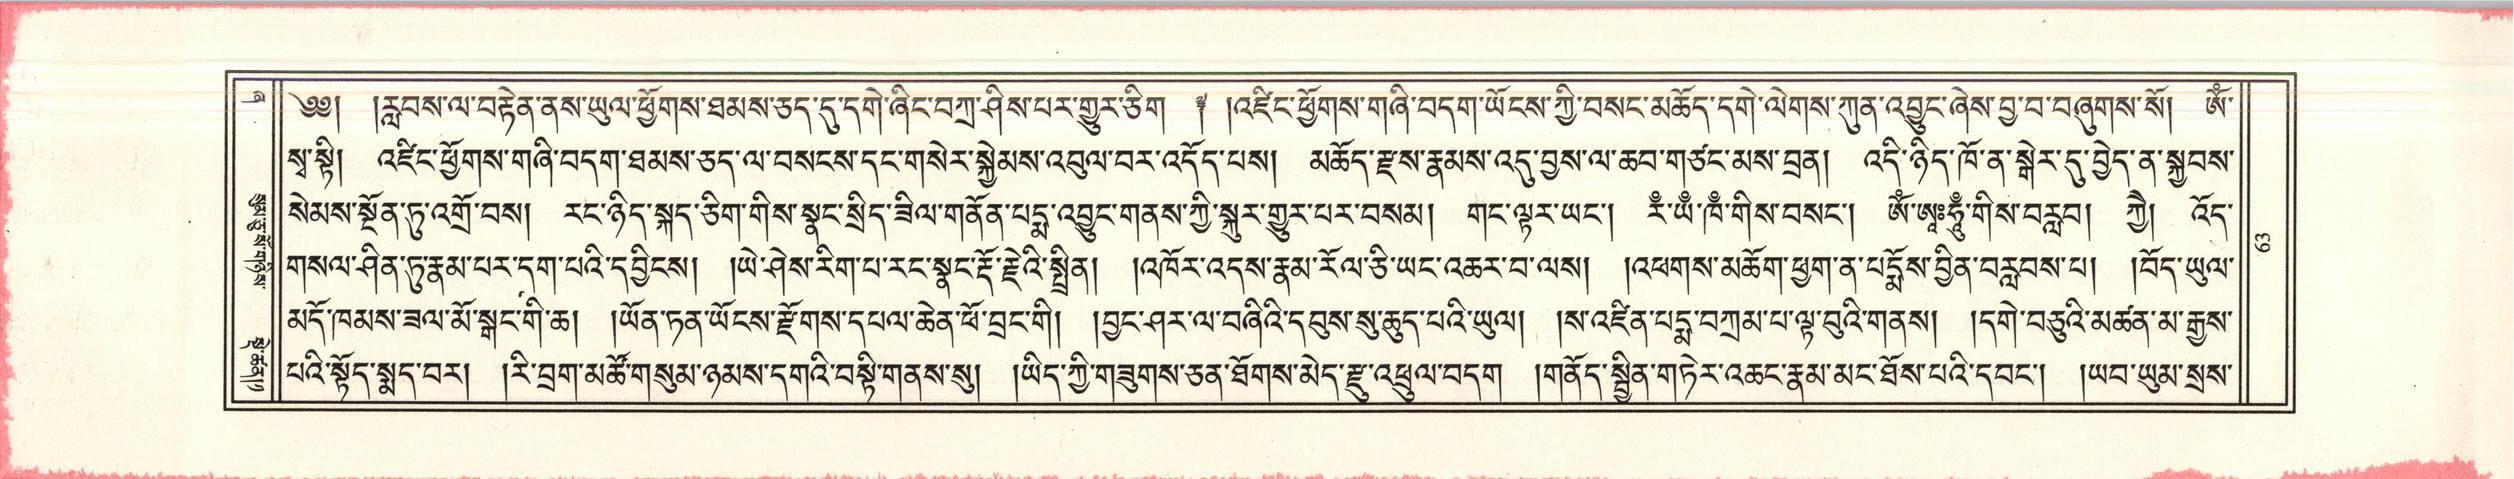

In [3]:
test_pages = "Data\Testing\KhyentseWangpo"
test_imgs = natsorted(glob(f"{test_pages}/*.jpg"))
print(f"Images: {len(test_imgs)}")

test_idx = 3
test_img = test_imgs[test_idx]

ShowImage(test_img)

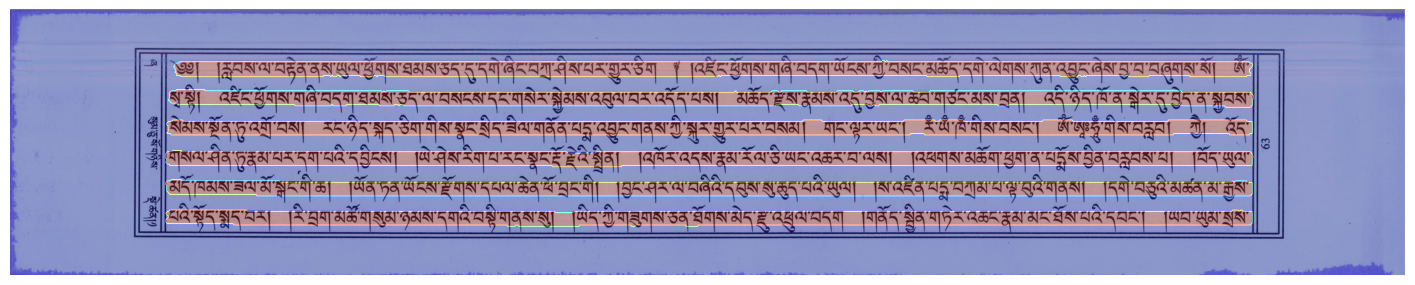

In [6]:
# preview line detection
original_image = cv2.imread(test_imgs[test_idx], 1)
pred_line_images, pred_mask, _, _ = line_detector.run(original_image)

plt.figure(figsize=(18, 6))
plt.axis('off')
plt.imshow(original_image)
plt.imshow(pred_mask, cmap='jet', alpha=0.4)

3


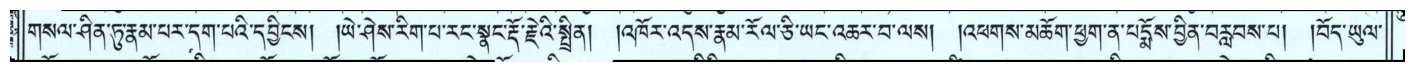

In [9]:
line_idx = random.randint(0, len(pred_line_images) - 1)
print(line_idx)
plt.figure(figsize=(18, 8))
plt.axis("off")
plt.imshow(pred_line_images[line_idx])

In [10]:
# OCR on a single line sample
wylie_results, raw_prediction = ocr_model.run(pred_line_images[line_idx])
print(wylie_results)
unicode_results = wylie_converter.toUnicode(wylie_results)
print(unicode_results)

gsal shin tu rnam par dag pa'i dbyings/_/ye shes rig pa rang snang rdo rje'i sprin/_/'khor 'das rnam rol ci yang 'char ba las/_/'phags mchog phyag na pad+mos byin brlabs pa/_/bod yul 
གསལ་ཤིན་ཏུ་རྣམ་པར་དག་པའི་དབྱིངས། །ཡེ་ཤེས་རིག་པ་རང་སྣང་རྡོ་རྗེའི་སྤྲིན། །འཁོར་འདས་རྣམ་རོལ་ཅི་ཡང་འཆར་བ་ལས། །འཕགས་མཆོག་ཕྱག་ན་པདྨོས་བྱིན་བརླབས་པ། །བོད་ཡུལ་


#### Run batched version

In [7]:
# run batched version
batched_results = ocr_model.run_batched(pred_line_images)

for result in batched_results:
    print(wylie_converter.toUnicode(result))

༄༅། །རླབས་ལ་བརྟེན་ནས་ཡུལ་ཕྱོགས་ཐམས་ཅད་དུ་དགེ་ཞིང་བཀྲ་ཤིས་པར་གྱུར་ཅིག ༈ །འཛིང་ཕྱོགས་གཞི་བདག་ཡོངས་ཀྱི་བསང་མཆོད་དགེ་ལེགས་ཀུན་འབྱུང་ཞེས་བྱ་བ་བཞུགས་སོ། ཨོཾ་
སྭ་སྟི། འཛིང་ཕྱོགས་གཞི་བདག་ཐམས་ཅད་ལ་བསངས་དང་གསེར་སྐྱེམས་འབུལ་བར་འདོད་པས། མཆོད་རྫས་རྣམས་འདུ་བྱས་ལ་ཆབ་གཙང་མས་བྲན། འདི་ཉིད་ཁོ་ན་སྒེར་དུ་བྱེད་ན་སྐྱབས་
སེམས་སྔོན་ཏུ་འགྲོ་བས། རང་ཉིད་སྐད་ཅིག་གིས་སྣང་སྲིད་ཟིལ་གནོན་པདྨ་འབྱུང་གནས་ཀྱི་སྐུར་གྱུར་པར་བསམ། གང་ལྟར་ཡང་། རྃ་ཡྃ་ཁྃ་གིས་བསང་། ཨོཾ་ཨཱཿཧཱུྃ་གིས་བརླབ། ཀྱི། འོད་
གསལ་ཤིན་ཏུ་རྣམ་པར་དག་པའི་དབྱིངས། །ཡེ་ཤེས་རིག་པ་རང་སྣང་རྡོ་རྗེའི་སྤྲིན། །འཁོར་འདས་རྣམ་རོལ་ཅི་ཡང་འཆར་བ་ལས། །འཕགས་མཆོག་ཕྱག་ན་པདྨོས་བྱིན་བརླབས་པ། །བོད་ཡུལ་
མདོ་ཁམས་ཟལ་མོ་སྒང་གི་ཆ། །ཡོན་ཏན་ཡོངས་རྫོགས་དཔལ་ཆེན་ཕོ་བྲང་གི། །བྱང་ཤར་ལ་བཞིའི་དབུས་སུ་ཆུད་པའི་ཡུལ། །ས་འཛིན་པདྨ་བཀྲམ་པ་ལྟ་བུའི་གནས། །དགེ་བཅུའི་མཚན་མ་རྒྱས་
པའི་སྣོད་སྨད་བར། །རི་བྲག་མཚོ་གསུམ་ཉམས་དགུའི་བསྟི་གནས་སུ། །ཡིད་ཀྱི་གཟུགས་ཅན་ཐོགས་མེད་རྫུ་འཕྲུལ་བདག །གནོད་སྦྱིན་གཏེར་འཆང་རྣམ་མང་ཐོས་པའི་དབང་། །ཡབ་ཡུམ་སྲས་


##### Run on a directory of images

In [8]:
xml_exporter = PageXML(image_dir=test_pages)
prodigy_line_exporter = ProdigyLines(image_dir=test_pages)
text_exporter = TextOutput(image_dir=test_pages)

In [9]:
## run on test images in Data/
for test_img in test_imgs:
    image = cv2.imread(test_img, 1)
    image_name = os.path.basename(test_img).split(".")[0]
    predicted_text_lines = []
    predicted_lines, _, text_bbox, line_boxes = line_detector.run(image)

    for line in predicted_lines:
        wylie_results, _ = ocr_model.run(line)
        unicode_results = wylie_converter.toUnicode(wylie_results)
        predicted_text_lines.append(unicode_results)

    xml_exporter.export(
        image=image,
        image_dir=test_imgs,
        image_name=image_name,
        text_bbox=text_bbox,
        line_boxes=line_boxes,
        line_images=predicted_lines,
        text_lines=predicted_text_lines,
    )
    prodigy_line_exporter.export(
        image=image,
        image_dir=test_imgs,
        image_name=image_name,
        text_bbox=text_bbox,
        line_boxes=line_boxes,
        line_images=predicted_lines,
        text_lines=predicted_text_lines,
    )
    text_exporter.export(
        image=image,
        image_dir=test_imgs,
        image_name=image_name,
        text_bbox=text_bbox,
        line_boxes=line_boxes,
        line_images=predicted_lines,
        text_lines=predicted_text_lines,
    )

In [10]:
def save_prediction(image_name, original_image, predicted_mask, out_path, alpha=0.6):
    original_image = original_image.astype(np.float32)
    predicted_mask = predicted_mask.astype(np.float32)
    predicted_mask = cv2.cvtColor(predicted_mask, cv2.COLOR_GRAY2RGB)
    cv2.addWeighted(predicted_mask, alpha, original_image, 1 - alpha, 0, original_image)
    target_path = os.path.join(out_path, f"{image_name}.jpg")
    cv2.imwrite(target_path, original_image)


def run_pipeline(
    image_dir: str,
    images: list[str],
    mode: str = "simple",
    decoding: str = "unicode",
    write_control_image: bool = False,
) -> None:
    volume_name = os.path.basename(image_dir)

    xml_exporter = PageXML(image_dir=image_dir)
    prodigy_line_exporter = ProdigyLines(image_dir=image_dir)
    text_exporter = TextOutput(image_dir=image_dir)

    if write_control_image:
        control_out = os.path.join(image_dir, "line_predictions")

        if not os.path.exists(control_out):
            os.makedirs(control_out)

    for idx in tqdm(range(len(images)), desc=volume_name):
        image = cv2.imread(images[idx], 1)
        image_name = os.path.basename(images[idx]).split(".")[0]

        predicted_lines, pred_image, text_bbox, line_boxes = line_detector.run(image)

        if len(predicted_lines) == 0:
            continue

        if write_control_image:
            save_prediction(image_name, image, pred_image, control_out)

        if mode == "batched":
            predicted_text_lines = ocr_model.run_batched(predicted_lines)

            if decoding == "unicode":
                predicted_text_lines = [
                    wylie_converter.toUnicode(x) for x in predicted_text_lines
                ]

        else:
            predicted_text_lines = []
            for line in predicted_lines:
                text = ocr_model.run(line)

                if decoding == "unicode":
                    text = wylie_converter.toUnicode(text)
                predicted_text_lines.append(text)

            print(predicted_text_lines)

        xml_exporter.export(
            image,
            image_dir,
            image_name,
            text_bbox,
            line_boxes,
            predicted_lines,
            predicted_text_lines,
        )

        prodigy_line_exporter.export(
            image,
            image_dir,
            image_name,
            text_bbox,
            line_boxes,
            predicted_lines,
            predicted_text_lines,
        )

        text_exporter.export(
            image,
            image_dir,
            image_name,
            text_bbox,
            line_boxes,
            predicted_lines,
            predicted_text_lines,
        )

#### run inference from a IIIF manifest
- see run_easter_inference.py for a cli example

In [11]:
### download a test volume from: https://library.bdrc.io/show/bdr:W3PD1002
manifest_url = "https://iiifpres.bdrc.io/vo:bdr:I1KG81137/manifest"
iif_downloader = IIIFDownloader(output_dir="Data")
iif_downloader.download(manifest_url, file_limit=20)

volume = iif_downloader.get_download_dir()
volume_images = natsorted(glob(f"{volume}/*.jpg"))

print(f"Test images: {len(volume_images)}")

100%|██████████| 20/20 [00:00<00:00, 1429.21it/s]

Test images: 20


In [12]:
# run inference
run_pipeline(
    volume, volume_images, mode="batched", decoding="unicode", write_control_image=True
)

I1KG81137: 100%|██████████| 20/20 [00:28<00:00,  1.45s/it]
